In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
backend=AerSimulator()
# backend=FakeKyiv()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:


I = np.array([[1,0],[0,1]])
X = np.array([[0,1],[1,0]])
Y = np.array([[0,-1j],[1j,0]])
Z = np.array([[1,0],[0,-1]])

m = np.array([[1, 0, 0, 0],
                 [0, 2, -1, 0],
                 [0, -1, 2, -1],
                 [0, 0, -1, 2]])
b = np.array([0,np.sqrt(2)/2,0.5,0.5])
nb_qubits = 2

In [3]:
d,u = np.linalg.eig(m)
d

array([3.41421356, 2.        , 0.58578644, 1.        ])

In [4]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([2.77555756e-17+1.11022302e-16j, 7.07106781e-01-2.22044605e-16j,
       5.00000000e-01+2.77555756e-17j, 5.00000000e-01+5.55111512e-17j])

In [5]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(k,l):
        return np.kron(k,l)
    M1 = (np.dot(np.dot(Ub,tensor(z,I)),np.conj(Ub.T))
        + np.dot(np.dot(Ub,tensor(I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [6]:
d,u = np.linalg.eig(A)
d

array([7.81178959e+00+7.77246932e-31j, 6.55662219e-01+8.60655466e-33j,
       2.09320836e+00+1.04677763e-30j, 6.59740229e-17-6.49339758e-31j])

In [7]:

U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
 
u1gate = UnitaryGate(U1)
u2gate = UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)


C_u1gate=u1gate.control()
C_u2gate=u2gate.control()
C_u3gate=u3gate.control()
C_u4gate=u4gate.control()
    

In [8]:

def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc


depth=2
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)

# Parameters = np.array([random.random() for _ in range(0, nb_params)])
Parameters = np.array([0.52822308, 0.40519007, 0.48765494, 0.56605484, 0.25056377,
       0.60720049, 0.53942809, 0.61184558, 0.99554639, 0.74489715,
       0.81785207, 0.25282619, 0.41243963, 0.11381233, 0.76354501,
       0.12637757, 0.54608607, 0.65329402, 0.20654193, 0.89865501,
       0.5440122 , 0.26823429, 0.24008469, 0.44891939, 0.56125941,
       0.05261654, 0.02638421, 0.06759133, 0.32614957, 0.39266204,
       0.19674497, 0.49752617, 0.77267437, 0.36766943, 0.13459572,
       0.3618098 ])



In [9]:

def circ(parameters):
    x=QuantumRegister(6)
    c=ClassicalRegister(4)
    circuit = QuantumCircuit(x,c)
    phi=parameters
    circuit=circuit.compose(ansatz(parameters),x[4:6])
    circuit.h(x[0:4])

#Apply the C-U operations where the controlled qubits are the qubits of the register x and the target from y    
    circuit.append(C_u1gate, [x[0],x[4],x[5]])    
    circuit.append(C_u2gate, [x[1],x[4],x[5]])    
    circuit.append(C_u3gate, [x[2],x[4],x[5]])    
    circuit.append(C_u4gate, [x[3],x[4],x[5]])    

#Apply the inverse QFT on the x register   
    circuit &= QFT(num_qubits=4, approximation_degree=0, do_swaps=True, 
                   inverse=True, insert_barriers=False, name='qft')
    circuit.measure(x[0:4],c)       
    return circuit

In [ ]:
# circ(parameters).draw("mpl") 

In [11]:
shots = 100000
def cost(parameters):
    job = backend.run(pm.run(circ(parameters)),shots = shots).result()
    result = job.get_counts(0)
    res = 1 - result['0000']/shots
    return res
# cost(parameters)


In [12]:
from qiskit_algorithms.optimizers import GradientDescent

learning_rate=0.1
def save(nfev,parameters,cost,stepsize):
    global Cost,Params
    print(nfev,cost)
    Cost.append(cost)
    Params.append(parameters)
Cost = []
Params = []

optimizer= GradientDescent(maxiter = 500,learning_rate=learning_rate,tol=1e-4,callback=save)
optimizer.minimize(x0 = parameters,fun = cost,jac=None)

/tmp/ipykernel_2685508/284935469.py:19: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits=4, approximation_degree=0, do_swaps=True,


13 0.8954
26 0.87833
39 0.8528
52 0.8331500000000001
65 0.8075600000000001
78 0.7758700000000001
91 0.74224
104 0.70139
117 0.6719200000000001
130 0.62541
143 0.5774
156 0.5501499999999999
169 0.50468
182 0.47285999999999995
195 0.45655
208 0.42771000000000003
221 0.38234
234 0.36227
247 0.3317
260 0.29906999999999995
273 0.27508
286 0.25119
299 0.24080000000000001
312 0.21058
325 0.19094999999999995
338 0.17576999999999998
351 0.16218999999999995
364 0.15210999999999997
377 0.12746000000000002
390 0.11890999999999996
403 0.10523000000000005
416 0.09214999999999995
429 0.08520000000000005
442 0.07891000000000004
455 0.06805000000000005
468 0.061840000000000006
481 0.05759000000000003
494 0.05405000000000004
507 0.04918
520 0.04239999999999999
533 0.04003000000000001
546 0.03646000000000005
559 0.034969999999999946
572 0.03068000000000004
585 0.029549999999999965
598 0.02624000000000004
611 0.022669999999999968
624 0.022159999999999958
637 0.020159999999999956
650 0.018769999999999953
6

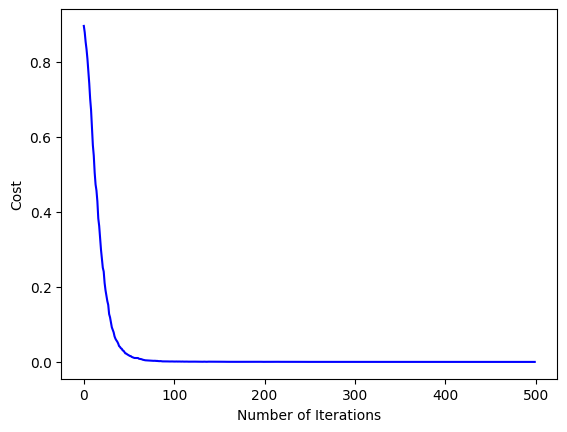

In [13]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [14]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [15]:
e = []
F =[ ]
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(Psi,b)
    e.append(b - Psi/norm)
    f = abs(np.dot(Psi,b))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

Text(0.5, 0, 'Iteration')

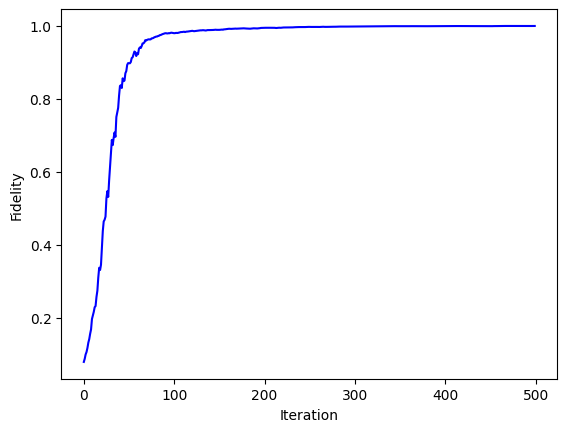

In [16]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(F)),F,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Fidelity')
plt.xlabel('Iteration')


In [17]:
min(norm_e)*100

1.907530512011069

Text(0.5, 0, 'Iteration')

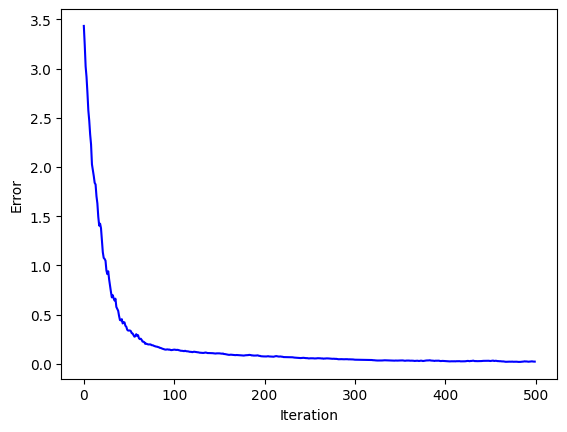

In [18]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(norm_e)),norm_e,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Error')
plt.xlabel('Iteration')

In [19]:
norm_e[np.argmax(F)]

0.01907530512011069

In [20]:
X_opt  = np.array(Statevector(ansatz(Params[-1])))
psi = m@X_opt
psi = psi/np.linalg.norm(psi)

In [21]:
ef = abs(np.array(e[np.argmax(F)]))
ef

array([0.0056696 , 0.00706484, 0.01385969, 0.00947206])

In [23]:
print(F)

[0.07819026870294828, 0.08680063719026822, 0.0987344875655219, 0.10536763091862483, 0.11648915295245588, 0.13110783735014908, 0.1408146910962489, 0.15535626553008705, 0.16739316284466074, 0.1958099372120502, 0.20531596907129315, 0.215342576557303, 0.22813493539280766, 0.23141525940602176, 0.2564116764672341, 0.2734770672270425, 0.3095927971223816, 0.3364685780494285, 0.33024860399049094, 0.3447519007435775, 0.39044217214439236, 0.43710364223096304, 0.4633974025676227, 0.46808127411809725, 0.47670731985150555, 0.5264235283545456, 0.5463137742205287, 0.5307970915327624, 0.5759000641672913, 0.6132521933275495, 0.6515098493867494, 0.6870008125953514, 0.6728171265642452, 0.6923898156510022, 0.707438654602175, 0.6954760217968536, 0.7498943166560246, 0.7621625077615739, 0.7748261482131303, 0.8086205774573513, 0.8349275241791793, 0.8371304264851043, 0.8294225953348913, 0.8559792367535725, 0.8480794768966495, 0.8496128461578326, 0.8699441457910649, 0.8757531398145618, 0.8927897407999614, 0.8976